# Quick-look for KUL-TN-20 simulations

This notebook can be used to have a quicklook at the that product for the simulations described in PLATO-PL-TN-0020. Note that the `LightCurve` class used to analyse the data assumes a identical structure of the data products as they are delivered on the KU Leuven FTP server.

### Setup notebook

In [1]:
# Alow changes to the PlatoSim code outside this notebook
%load_ext autoreload
%autoreload 2

# Configure figure in notebook
%matplotlib notebook

### Imports

In [2]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# PlatoSim libraries
from platosim.lightcurve import LightCurve
from platosim.matplotlibrc import setup_notebook
setup_notebook()

In [3]:
# Load all data for a single star
idir = "/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P1_corrected/000000004"
phot = LightCurve(idir, mode="multi")

# To fetch a specific light curve, use instead:
# lc = LightCurve(f"{idir}/000000083/000000083_Ncam1.1_Q23.ftr")

In [4]:
# Unzip all compressed files for the same star
phot.unpack()

In [5]:
# Fetch all feather filenames
filenames = phot.files("ftr")
filenames[0]

'/STER/platodata/PLATOSIM/simulations_PLATO-PL-KUL-TN-0020/P1_corrected/000000004/000000004_Ncam1.4_Q23.ftr'

In [6]:
# Fetch the first light curve for this star
lc = LightCurve(filenames[0])
lc.data().head()

,flux,cx,cy,bg,flux_err,cx_err,time,cy_err,bg_err,chi2,iter,lamb
0,569571.862619,3.416804,2.570257,1375.713585,856.809917,0.000617,171072012.5,0.000771,13.667106,40.569286,6.0,3333.333333
1,569981.668856,3.419191,2.568931,1418.328107,857.271745,0.000619,171072037.5,0.000770,13.720945,41.394912,8.0,0.000015
2,567453.679979,3.418011,2.570909,1396.604937,855.873697,0.000620,171072062.5,0.000771,13.703087,43.271269,6.0,3333.333333
3,570337.293167,3.420920,2.575798,1403.607583,857.455990,0.000619,171072087.5,0.000769,13.705912,46.772334,7.0,33333.333333
4,570036.700251,3.418867,2.574390,1426.702159,857.510846,0.000618,171072112.5,0.000770,13.743900,43.030494,6.0,100000.000000


In [7]:
# Get target star information
star = lc.star_info(phot.files("cat")[0])
print(f"""
Pmag : {star[0]}
rOA  : {star[1]}
rCOB : {star[2]}
nCon : {star[3]}
rCon : {star[4]}
dMag : {star[5]}
SPR  : {star[6]}
""")


Pmag : 9.55
rOA  : 12.242354574214627
rCOB : 0.6965414102148416
nCon : 8
rCon : 1.1158414279326514
dMag : 0.8300000000000018
SPR  : 1.6775642953460468



In [8]:
# Get noise-less light curve
lc.varsource()

,time,gran,puls,sum
0,171072000.0,22.792661,-0.707734,22.084927
1,171072025.0,26.577298,-7.865304,18.711994
2,171072050.0,20.054023,-12.840985,7.213037
3,171072075.0,16.220701,-14.127791,2.092909
4,171072100.0,6.331240,-11.486065,-5.154825
...,...,...,...,...
622075,186623875.0,21.525189,-7.551232,13.973957
622076,186623900.0,26.051495,-5.238417,20.813078
622077,186623925.0,33.261030,-1.378547,31.882483
622078,186623950.0,30.923211,3.029651,33.952862


<IPython.core.display.Javascript object>


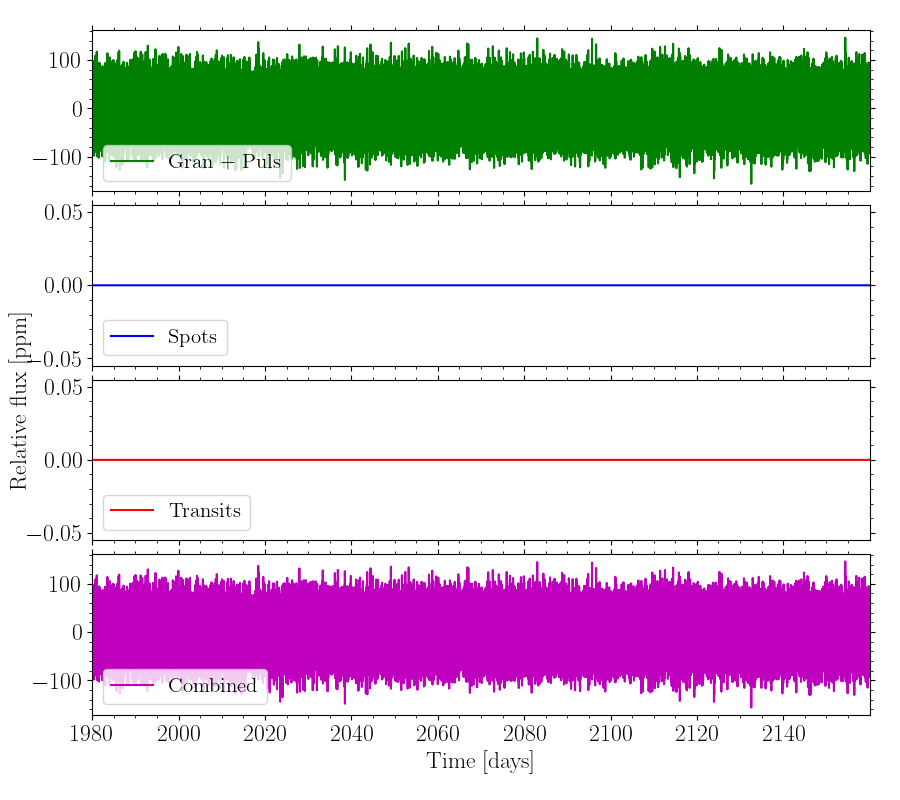

In [9]:
# Plot the input noise-less light curve
fig, ax = lc.plot_varsource();

<IPython.core.display.Javascript object>


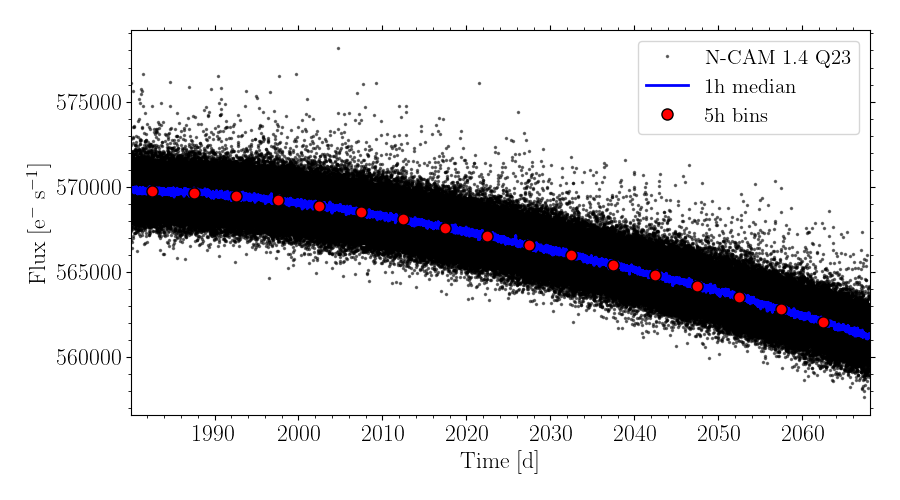

In [10]:
# Plot the simulation, running median, and binned data
fig, ax = lc.plot(time_unit="d", binsize=5, median_filter=1);

<IPython.core.display.Javascript object>


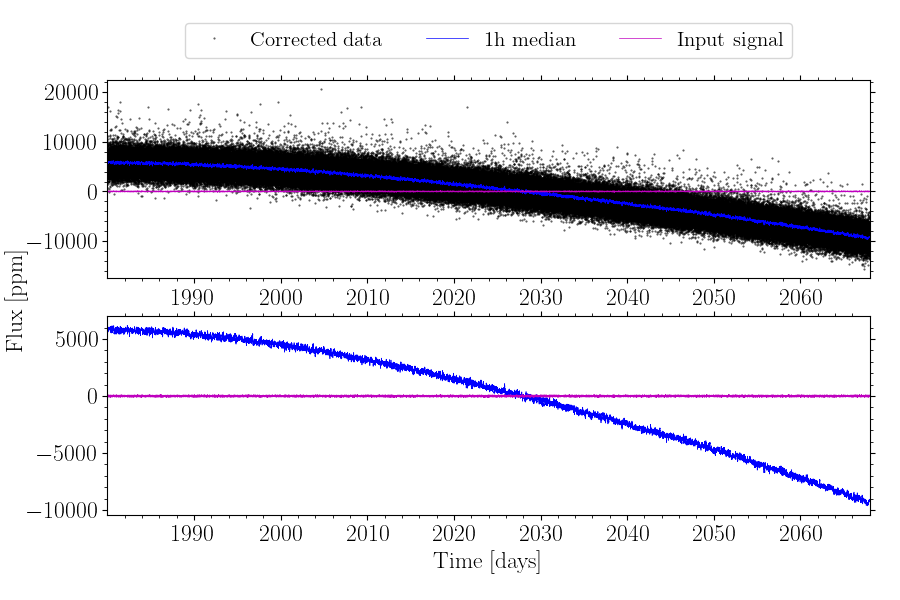

In [11]:
# Plot a quick O-C comparison plot 
fig, ax = lc.plot_oc();

<IPython.core.display.Javascript object>


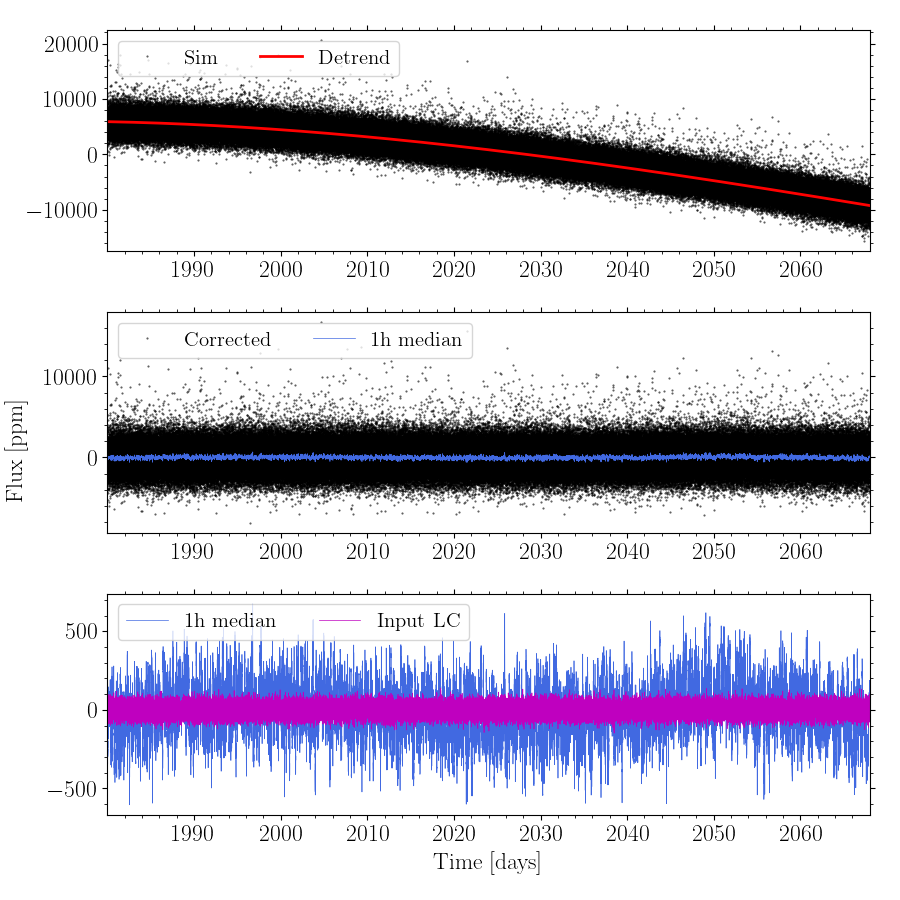

In [12]:
# Detrend light curve
lc.plot_detrend(poly_deg=3, binsize=1);

In [13]:
# Get NSR per 1h for detrended light curve 
lc.detrend(poly_deg=3)
lc.getNSR(column="flux_det", binhour=1, influx="ppm")

74.04483392621601

In [14]:
# With the long trend systematics the NSR is somewhat larger
lc.getNSR()

130.7056009018528

In [15]:
# Remove files again to keep server clean
phot.remove()